In [1]:
%pip install -q python-dotenv langchain-openai


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
from dotenv import load_dotenv

load_dotenv()


True

In [3]:
from langchain_openai import ChatOpenAI

query = "Hello, world!"
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

llm.invoke(query)



AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 11, 'total_tokens': 21, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_b376dfbbd5', 'id': 'chatcmpl-BJhKqpEVh9ABSFMd8gOLmTVqE9gve', 'finish_reason': 'stop', 'logprobs': None}, id='run-43695a36-d85e-4adc-8103-7516123ded33-0', usage_metadata={'input_tokens': 11, 'output_tokens': 10, 'total_tokens': 21, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [4]:
# State, Node, Edge, Conditional Edge

# State: 상태 -> 노드의 입력 및 출력
# Node: 노드 -> Agent가 수행하는 작업 (다른 에이전트가 될수 있고 함수가 될수 있음)
# Edge: 간선 -> 노드와 노드 사이의 연결
# Conditional Edge: 조건 간선 -> 조건에 따라 다른 노드로 이동



In [5]:
%pip install -q langgraph


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [6]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph.message import add_messages
from langchain_core.messages import AnyMessage

# State 정의
class AgentState(TypedDict):
    messages: list[Annotated[AnyMessage, add_messages]]

In [7]:
from langgraph.graph import StateGraph

# 그래프 빌더 정의
graph_builder = StateGraph(AgentState)

In [8]:
# 노드 및 엣지 추가
def generate(state: AgentState) -> AgentState:
    message = state["messages"]
    ai_message = llm.invoke(message)
    return {"messages": [ai_message]}


In [9]:
from langgraph.graph import START, END

graph_builder.add_node("generate", generate)
graph_builder.add_edge(START, "generate")
graph_builder.add_edge("generate", END)

In [10]:
graph = graph_builder.compile()

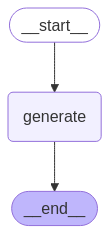

In [11]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [12]:
from langchain_core.messages import HumanMessage

# 수행
initial_state = {'messages': [HumanMessage(query)]}
graph.invoke(initial_state)

{'messages': [AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 11, 'total_tokens': 21, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_b376dfbbd5', 'id': 'chatcmpl-BJhMMYICWaBffkzhXmbXv15ClPa1D', 'finish_reason': 'stop', 'logprobs': None}, id='run-6ad970a9-6a72-4ff5-9b8e-00f1072e6319-0', usage_metadata={'input_tokens': 11, 'output_tokens': 10, 'total_tokens': 21, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}